# WellCo Churn Prediction — EDA
Phase 1: Exploratory Data Analysis (training data only)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

DATA = '../assignment_instructions/train/'

labels   = pd.read_csv(DATA + 'churn_labels.csv', parse_dates=['signup_date'])
app      = pd.read_csv(DATA + 'app_usage.csv',    parse_dates=['timestamp'])
web      = pd.read_csv(DATA + 'web_visits.csv',   parse_dates=['timestamp'])
claims   = pd.read_csv(DATA + 'claims.csv',       parse_dates=['diagnosis_date'])

print('labels  :', labels.shape)
print('app     :', app.shape)
print('web     :', web.shape)
print('claims  :', claims.shape)

labels  : (10000, 4)
app     : (97789, 3)
web     : (259340, 5)
claims  : (64576, 3)


## 1. churn_labels.csv — target & outreach

In [2]:
print('=== dtypes ===')
print(labels.dtypes)
print('\n=== nulls ===')
print(labels.isnull().sum())
print('\n=== duplicates ===')
print('duplicate member_ids:', labels['member_id'].duplicated().sum())
print('\n=== value counts ===')
print('churn\n',    labels['churn'].value_counts())
print('outreach\n', labels['outreach'].value_counts())

=== dtypes ===
member_id               int64
signup_date    datetime64[us]
churn                   int64
outreach                int64
dtype: object

=== nulls ===
member_id      0
signup_date    0
churn          0
outreach       0
dtype: int64

=== duplicates ===
duplicate member_ids: 0

=== value counts ===
churn
 churn
0    7979
1    2021
Name: count, dtype: int64
outreach
 outreach
0    6016
1    3984
Name: count, dtype: int64


In [3]:
# Churn rate overall and by outreach group
overall = labels['churn'].mean()
by_outreach = labels.groupby('outreach')['churn'].agg(['mean','count'])
by_outreach.columns = ['churn_rate', 'n']
print(f'Overall churn rate: {overall:.3f}')
print('\nChurn rate by outreach group:')
print(by_outreach)

Overall churn rate: 0.202

Churn rate by outreach group:
          churn_rate     n
outreach                  
0           0.207447  6016
1           0.194026  3984


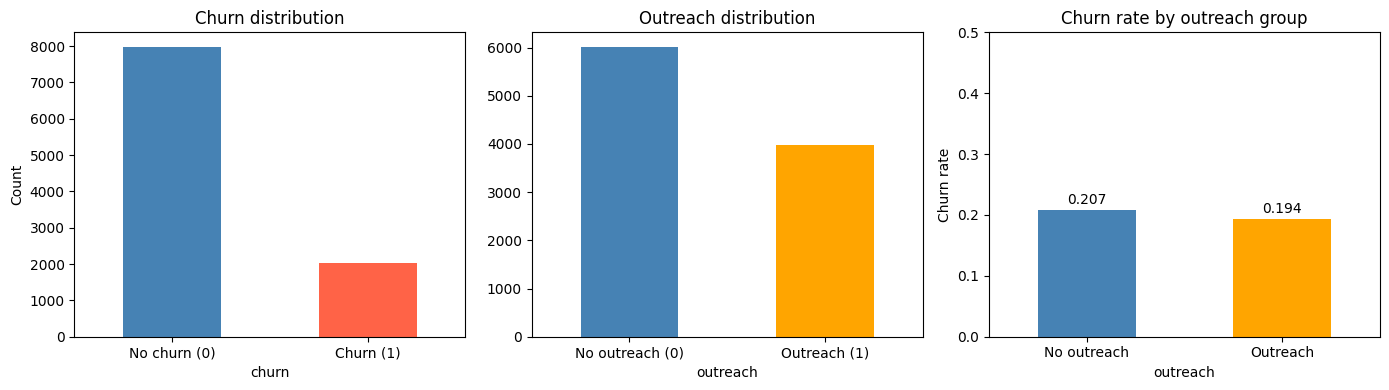

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# churn distribution
labels['churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Churn distribution')
axes[0].set_xticklabels(['No churn (0)', 'Churn (1)'], rotation=0)
axes[0].set_ylabel('Count')

# outreach distribution
labels['outreach'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','orange'])
axes[1].set_title('Outreach distribution')
axes[1].set_xticklabels(['No outreach (0)', 'Outreach (1)'], rotation=0)

# churn rate by outreach
by_outreach['churn_rate'].plot(kind='bar', ax=axes[2], color=['steelblue','orange'])
axes[2].set_title('Churn rate by outreach group')
axes[2].set_xticklabels(['No outreach', 'Outreach'], rotation=0)
axes[2].set_ylabel('Churn rate')
axes[2].set_ylim(0, 0.5)
for bar in axes[2].patches:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_churn_labels.png', dpi=120)
plt.show()

signup_date range: 2024-01-01 00:00:00 -> 2025-05-31 00:00:00
member_id range: 1 -> 10000


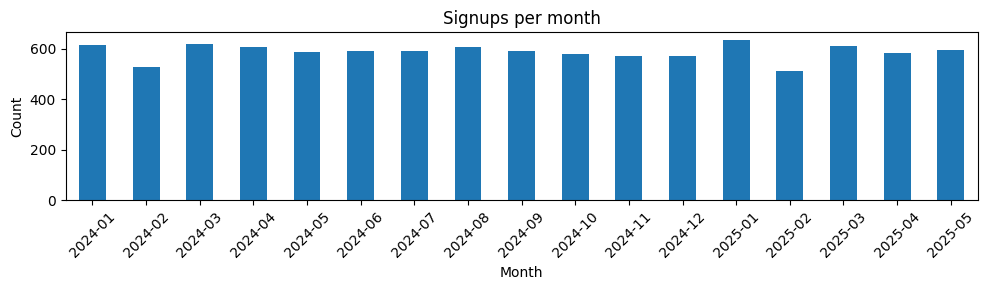

In [5]:
# signup_date range and distribution
print('signup_date range:', labels['signup_date'].min(), '->', labels['signup_date'].max())
print('member_id range:',   labels['member_id'].min(), '->', labels['member_id'].max())

fig, ax = plt.subplots(figsize=(10, 3))
labels['signup_date'].dt.to_period('M').value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Signups per month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_signups.png', dpi=120)
plt.show()

In [6]:
# Churn rate by signup cohort (month)
labels['signup_month'] = labels['signup_date'].dt.to_period('M')
cohort_churn = labels.groupby('signup_month')['churn'].agg(['mean','count'])
cohort_churn.columns = ['churn_rate', 'n']
print(cohort_churn.sort_index())

              churn_rate    n
signup_month                 
2024-01         0.131494  616
2024-02         0.153700  527
2024-03         0.117932  619
2024-04         0.163097  607
2024-05         0.166384  589
2024-06         0.187184  593
2024-07         0.141653  593
2024-08         0.197694  607
2024-09         0.177066  593
2024-10         0.184165  581
2024-11         0.215412  571
2024-12         0.215789  570
2025-01         0.231861  634
2025-02         0.259766  512
2025-03         0.254098  610
2025-04         0.285959  584
2025-05         0.360269  594


## 2. app_usage.csv

In [7]:
print('=== nulls ===')
print(app.isnull().sum())
print('\n=== event_type unique values ===')
print(app['event_type'].value_counts())
print('\n=== timestamp range ===')
print(app['timestamp'].min(), '->', app['timestamp'].max())
print('\n=== members with app events ===')
print(f'{app["member_id"].nunique()} unique members out of {labels["member_id"].nunique()}')

=== nulls ===
member_id     0
event_type    0
timestamp     0
dtype: int64

=== event_type unique values ===
event_type
session    97789
Name: count, dtype: int64

=== timestamp range ===
2025-07-01 00:00:00 -> 2025-07-14 23:59:51

=== members with app events ===
9998 unique members out of 10000


In [8]:
# Members in app but NOT in labels (and vice versa)
app_members    = set(app['member_id'].unique())
label_members  = set(labels['member_id'].unique())
print('App members not in labels:', len(app_members - label_members))
print('Label members not in app: ', len(label_members - app_members))

App members not in labels: 0
Label members not in app:  2


In [9]:
# Timestamps outside observation window (Jul 1–15 2025)
OBS_START = pd.Timestamp('2025-07-01')
OBS_END   = pd.Timestamp('2025-07-15 23:59:59')
out_of_window_app = app[(app['timestamp'] < OBS_START) | (app['timestamp'] > OBS_END)]
print(f'App events outside observation window: {len(out_of_window_app)}')
if len(out_of_window_app):
    print(out_of_window_app['timestamp'].describe())

App events outside observation window: 0


Sessions per member stats:
count    9998.000000
mean        9.780856
std         3.625525
min         1.000000
25%         7.000000
50%        10.000000
75%        12.000000
max        26.000000
dtype: float64

Members with 0 sessions (not in app file): 2


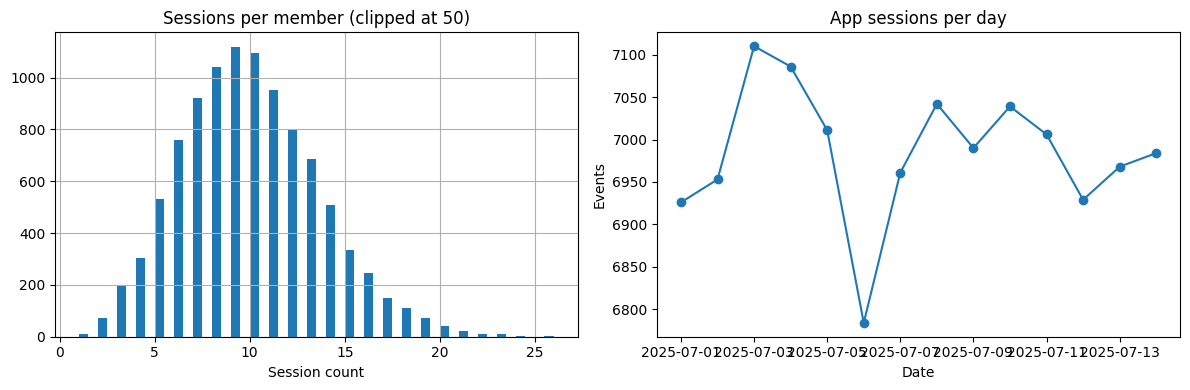

In [10]:
# Sessions per member distribution
sessions_per_member = app.groupby('member_id').size()
print('Sessions per member stats:')
print(sessions_per_member.describe())
print('\nMembers with 0 sessions (not in app file):', len(label_members - app_members))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sessions_per_member.clip(upper=50).hist(bins=50, ax=axes[0])
axes[0].set_title('Sessions per member (clipped at 50)')
axes[0].set_xlabel('Session count')

# sessions by day of observation window
app['day'] = app['timestamp'].dt.date
app.groupby('day').size().plot(ax=axes[1], marker='o')
axes[1].set_title('App sessions per day')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Events')
plt.tight_layout()
plt.savefig('eda_app_usage.png', dpi=120)
plt.show()

In [11]:
# Churn rate by app activity (active vs inactive)
sessions_per_member_df = sessions_per_member.reset_index()
sessions_per_member_df.columns = ['member_id', 'session_count']
merged_app = labels.merge(sessions_per_member_df, on='member_id', how='left').fillna({'session_count': 0})
merged_app['active'] = (merged_app['session_count'] > 0).astype(int)
print('Churn rate by app activity:')
print(merged_app.groupby('active')['churn'].agg(['mean','count']))

Churn rate by app activity:
           mean  count
active                
0       0.50000      2
1       0.20204   9998


## 3. web_visits.csv

In [12]:
print('=== nulls ===')
print(web.isnull().sum())
print('\n=== timestamp range ===')
print(web['timestamp'].min(), '->', web['timestamp'].max())
print('\n=== unique members ===')
print(web['member_id'].nunique())

=== nulls ===
member_id      0
url            0
title          0
description    0
timestamp      0
dtype: int64

=== timestamp range ===
2025-07-01 00:00:01 -> 2025-07-14 23:59:49

=== unique members ===
9975


In [13]:
# Timestamps outside observation window
out_of_window_web = web[(web['timestamp'] < OBS_START) | (web['timestamp'] > OBS_END)]
print(f'Web visits outside observation window: {len(out_of_window_web)}')
if len(out_of_window_web):
    print(out_of_window_web['timestamp'].describe())

Web visits outside observation window: 0


In [14]:
# URL domain analysis
web['domain'] = web['url'].str.extract(r'https?://([^/]+)')
print('Top domains:')
print(web['domain'].value_counts().head(20))

Top domains:
domain
portal.site       44325
example.com       39960
world.news        39007
media.hub         34548
care.portal       25471
living.better     25438
guide.wellness    25313
health.wellco     25278
Name: count, dtype: int64


In [15]:
# WellCo vs non-WellCo visits
web['is_wellco'] = web['domain'].str.contains('wellco', na=False)
print('WellCo vs non-WellCo visits:')
print(web['is_wellco'].value_counts())
print(f'\nWellCo visit share: {web["is_wellco"].mean():.3f}')

WellCo vs non-WellCo visits:
is_wellco
False    234062
True      25278
Name: count, dtype: int64

WellCo visit share: 0.097


In [16]:
# Non-WellCo URLs — are they noise or sabotage?
print('Top non-WellCo domains:')
print(web[~web['is_wellco']]['domain'].value_counts().head(20))
print('\nSample non-WellCo rows:')
print(web[~web['is_wellco']][['url','title','description']].sample(10, random_state=42))

Top non-WellCo domains:
domain
portal.site       44325
example.com       39960
world.news        39007
media.hub         34548
care.portal       25471
living.better     25438
guide.wellness    25313
Name: count, dtype: int64

Sample non-WellCo rows:
                                      url                   title  \
96943    https://living.better/stress/966        Stress reduction   
221154  https://living.better/recipes/672        High-fiber meals   
152590    https://living.better/heart/641  Cardiometabolic health   
93850      https://portal.site/travel/521        Top destinations   
247610  https://living.better/fitness/326       Exercise routines   
162941      https://world.news/sports/696        Match highlights   
56814        https://portal.site/pets/195            Dog training   
229915     https://care.portal/stress/555        Stress reduction   
41149        https://example.com/tech/673          Gadget roundup   
113650     https://portal.site/movies/448            New rel

Web visits per member stats:
count    9975.000000
mean       25.998997
std        17.209289
min         1.000000
25%        13.000000
50%        22.000000
75%        35.000000
max       140.000000
dtype: float64


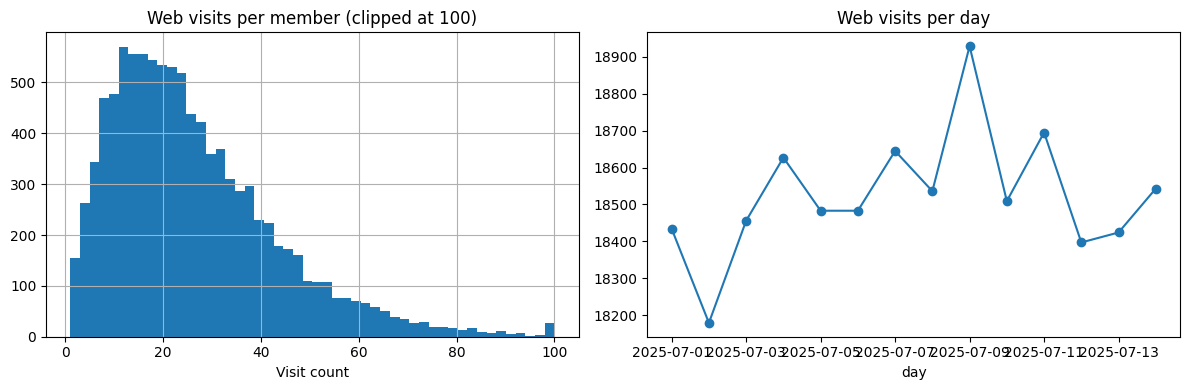

In [17]:
# Visit counts per member
visits_per_member = web.groupby('member_id').size()
print('Web visits per member stats:')
print(visits_per_member.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
visits_per_member.clip(upper=100).hist(bins=50, ax=axes[0])
axes[0].set_title('Web visits per member (clipped at 100)')
axes[0].set_xlabel('Visit count')

web['day'] = web['timestamp'].dt.date
web.groupby('day').size().plot(ax=axes[1], marker='o')
axes[1].set_title('Web visits per day')
plt.tight_layout()
plt.savefig('eda_web_visits.png', dpi=120)
plt.show()

In [18]:
# Health content visits (WellCo only)
wellco_visits = web[web['is_wellco']].copy()
print('Top WellCo page titles:')
print(wellco_visits['title'].value_counts().head(20))
print('\nTop WellCo URL path prefixes:')
wellco_visits['path_prefix'] = wellco_visits['url'].str.extract(r'wellco/([^/]+)')
print(wellco_visits['path_prefix'].value_counts().head(15))

Top WellCo page titles:
title
Lowering blood pressure       1475
Restorative sleep tips        1469
Stress reduction              1446
Sleep hygiene                 1435
Exercise routines             1434
Meditation guide              1427
Diabetes management           1411
Cholesterol friendly foods    1405
High-fiber meals              1404
Aerobic exercise              1399
HbA1c targets                 1391
Mediterranean diet            1386
Weight management             1380
Healthy eating guide          1380
Cardio workouts               1371
Cardiometabolic health        1359
Hypertension basics           1357
Strength training basics      1349
Name: count, dtype: int64

Top WellCo URL path prefixes:
path_prefix
sleep           2904
nutrition       2791
heart           2716
hypertension    1475
stress          1446
fitness         1434
mindfulness     1427
chronic         1411
recipes         1404
aerobic         1399
diabetes        1391
weight          1380
wellness        138

In [19]:
# Churn rate by web activity
web_members = set(web['member_id'].unique())
visits_df = visits_per_member.reset_index()
visits_df.columns = ['member_id', 'visit_count']
merged_web = labels.merge(visits_df, on='member_id', how='left').fillna({'visit_count': 0})
merged_web['active_web'] = (merged_web['visit_count'] > 0).astype(int)
print('Churn rate by web activity:')
print(merged_web.groupby('active_web')['churn'].agg(['mean','count']))

Churn rate by web activity:
                mean  count
active_web                 
0           0.080000     25
1           0.202406   9975


## 4. claims.csv

In [20]:
print('=== nulls ===')
print(claims.isnull().sum())
print('\n=== timestamp range ===')
print(claims['diagnosis_date'].min(), '->', claims['diagnosis_date'].max())
print('\n=== unique members ===')
print(claims['member_id'].nunique())
print('\n=== ICD code distribution ===')
print(claims['icd_code'].value_counts())

=== nulls ===
member_id         0
icd_code          0
diagnosis_date    0
dtype: int64

=== timestamp range ===
2025-07-01 00:00:00 -> 2025-07-14 00:00:00

=== unique members ===
9980

=== ICD code distribution ===
icd_code
Z71.3    9145
I10      9006
E11.9    8961
H10.9    5414
B34.9    5410
A09      5387
M54.5    5385
J00      5346
R51      5277
K21.9    5245
Name: count, dtype: int64


In [21]:
# Dates outside observation window
out_of_window_claims = claims[(claims['diagnosis_date'] < OBS_START) | (claims['diagnosis_date'] > OBS_END)]
print(f'Claims outside observation window: {len(out_of_window_claims)}')
if len(out_of_window_claims):
    print(out_of_window_claims['diagnosis_date'].describe())
    print(out_of_window_claims['diagnosis_date'].value_counts().sort_index())

Claims outside observation window: 0


In [22]:
# ICD codes not in the three expected codes
expected_icd = {'E11.9', 'I10', 'Z71.3'}
unexpected_icd = claims[~claims['icd_code'].isin(expected_icd)]
print(f'Unexpected ICD codes: {len(unexpected_icd)}')
if len(unexpected_icd):
    print(unexpected_icd['icd_code'].value_counts())

Unexpected ICD codes: 37464
icd_code
H10.9    5414
B34.9    5410
A09      5387
M54.5    5385
J00      5346
R51      5277
K21.9    5245
Name: count, dtype: int64


In [23]:
# Claims per member
claims_per_member = claims.groupby('member_id').size()
print('Claims per member stats:')
print(claims_per_member.describe())

# ICD code co-occurrence per member
icd_flags = claims.groupby(['member_id','icd_code']).size().unstack(fill_value=0).clip(upper=1)
icd_flags.columns = [f'has_{c}' for c in icd_flags.columns]
print('\nMembers with each ICD code:')
print(icd_flags.sum())
print('\nICD code co-occurrence:')
print(icd_flags.corr())

Claims per member stats:
count    9980.000000
mean        6.470541
std         2.568363
min         1.000000
25%         5.000000
50%         6.000000
75%         8.000000
max        18.000000
dtype: float64

Members with each ICD code:
has_A09      4139
has_B34.9    4202
has_E11.9    5880
has_H10.9    4159
has_I10      5887
has_J00      4108
has_K21.9    4062
has_M54.5    4154
has_R51      4043
has_Z71.3    5896
dtype: int64

ICD code co-occurrence:
            has_A09  has_B34.9  has_E11.9  has_H10.9   has_I10   has_J00  \
has_A09    1.000000   0.007541  -0.000252  -0.010668 -0.012203  0.012518   
has_B34.9  0.007541   1.000000  -0.015563  -0.003340 -0.021322  0.018293   
has_E11.9 -0.000252  -0.015563   1.000000  -0.012555  0.015531  0.003168   
has_H10.9 -0.010668  -0.003340  -0.012555   1.000000 -0.007153  0.001263   
has_I10   -0.012203  -0.021322   0.015531  -0.007153  1.000000 -0.010029   
has_J00    0.012518   0.018293   0.003168   0.001263 -0.010029  1.000000   
has_K21.9  0.

In [24]:
# Churn rate by ICD code presence
icd_merged = labels.merge(icd_flags.reset_index(), on='member_id', how='left')
icd_cols = [c for c in icd_merged.columns if c.startswith('has_')]
icd_merged[icd_cols] = icd_merged[icd_cols].fillna(0)
for col in [c for c in icd_merged.columns if c.startswith('has_')]:
    print(f'\nChurn rate by {col}:')
    print(icd_merged.groupby(col)['churn'].agg(['mean','count']))


Churn rate by has_A09:
             mean  count
has_A09                 
0.0      0.196042   5861
1.0      0.210679   4139

Churn rate by has_B34.9:
               mean  count
has_B34.9                 
0.0        0.203174   5798
1.0        0.200619   4202

Churn rate by has_E11.9:
               mean  count
has_E11.9                 
0.0        0.212864   4120
1.0        0.194558   5880

Churn rate by has_H10.9:
               mean  count
has_H10.9                 
0.0        0.202705   5841
1.0        0.201250   4159

Churn rate by has_I10:
             mean  count
has_I10                 
0.0      0.220763   4113
1.0      0.189061   5887

Churn rate by has_J00:
             mean  count
has_J00                 
0.0      0.198744   5892
1.0      0.206913   4108

Churn rate by has_K21.9:
               mean  count
has_K21.9                 
0.0        0.200067   5938
1.0        0.205071   4062

Churn rate by has_M54.5:
               mean  count
has_M54.5                 
0.0        0

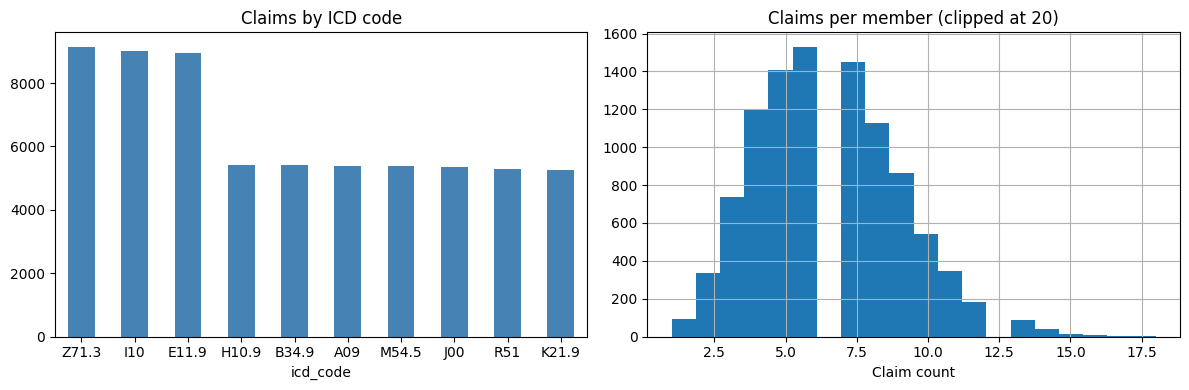

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

claims['icd_code'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Claims by ICD code')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

claims_per_member.clip(upper=20).hist(bins=20, ax=axes[1])
axes[1].set_title('Claims per member (clipped at 20)')
axes[1].set_xlabel('Claim count')

plt.tight_layout()
plt.savefig('eda_claims.png', dpi=120)
plt.show()

## 5. Cross-table linkage & data quality summary

In [26]:
# Which label members appear in each table?
label_set = set(labels['member_id'])
coverage = {
    'app_usage':  len(set(app['member_id'])    & label_set),
    'web_visits': len(set(web['member_id'])    & label_set),
    'claims':     len(set(claims['member_id']) & label_set),
}
print('Members in labels with data in each table:')
for k, v in coverage.items():
    print(f'  {k}: {v}/{len(label_set)} ({v/len(label_set):.1%})')

Members in labels with data in each table:
  app_usage: 9998/10000 (100.0%)
  web_visits: 9975/10000 (99.8%)
  claims: 9980/10000 (99.8%)


In [27]:
# Members with NO data in any table
any_data = set(app['member_id']) | set(web['member_id']) | set(claims['member_id'])
ghost_members = label_set - any_data
print(f'Label members with zero records across all tables: {len(ghost_members)}')
if ghost_members:
    ghost_df = labels[labels['member_id'].isin(ghost_members)]
    print('Churn rate for ghost members:', ghost_df['churn'].mean())
    print(ghost_df['churn'].value_counts())

Label members with zero records across all tables: 0


In [28]:
# Build a unified member-level frame and check correlations
sessions_df = app.groupby('member_id').size().reset_index(name='session_count')
web_df      = web.groupby('member_id').size().reset_index(name='visit_count')
claims_df   = claims.groupby('member_id').size().reset_index(name='claim_count')

member_df = (
    labels
    .merge(sessions_df, on='member_id', how='left')
    .merge(web_df,      on='member_id', how='left')
    .merge(claims_df,   on='member_id', how='left')
)
member_df[['session_count','visit_count','claim_count']] = \
    member_df[['session_count','visit_count','claim_count']].fillna(0)

print('Correlation with churn:')
print(member_df[['session_count','visit_count','claim_count','outreach','churn']].corr()['churn'])

Correlation with churn:
session_count   -0.078680
visit_count      0.003213
claim_count     -0.022455
outreach        -0.016362
churn            1.000000
Name: churn, dtype: float64


In [29]:
# Outreach as treatment: churn rates in 2x2 (outreach x activity)
member_df['any_app'] = (member_df['session_count'] > 0).astype(int)
pivot = member_df.groupby(['outreach','any_app'])['churn'].agg(['mean','count'])
pivot.columns = ['churn_rate','n']
print('Churn rate by outreach x app activity:')
print(pivot)

Churn rate by outreach x app activity:
                  churn_rate     n
outreach any_app                  
0        1          0.207447  6016
1        0          0.500000     2
         1          0.193872  3982


## 6. Potential data quality issues / sabotage flags

In [30]:
# Check: are non-WellCo web visits associated with different churn rates?
web_wellco_per = web.groupby('member_id')['is_wellco'].agg(['sum','count'])
web_wellco_per.columns = ['wellco_visits','total_visits']
web_wellco_per['nonwellco_visits'] = web_wellco_per['total_visits'] - web_wellco_per['wellco_visits']
web_wellco_per['wellco_ratio'] = web_wellco_per['wellco_visits'] / web_wellco_per['total_visits']

m = labels.merge(web_wellco_per.reset_index(), on='member_id', how='left')
m[['wellco_visits','total_visits','nonwellco_visits','wellco_ratio']] = \
    m[['wellco_visits','total_visits','nonwellco_visits','wellco_ratio']].fillna(0)
m['has_nonwellco'] = (m['nonwellco_visits'] > 0).astype(int)
print('Churn rate by presence of non-WellCo visits:')
print(m.groupby('has_nonwellco')['churn'].agg(['mean','count']))

Churn rate by presence of non-WellCo visits:
                   mean  count
has_nonwellco                 
0              0.096774     31
1              0.202428   9969


In [31]:
# Check: are there members with implausibly high activity?
print('Top 10 members by session count:')
print(sessions_df.sort_values('session_count', ascending=False).head(10))
print('\nTop 10 members by web visit count:')
print(web_df.sort_values('visit_count', ascending=False).head(10))
print('\nTop 10 members by claim count:')
print(claims_df.sort_values('claim_count', ascending=False).head(10))

Top 10 members by session count:
      member_id  session_count
4989       4990             26
4467       4468             24
1418       1419             24
7833       7836             24
2097       2098             23
234         235             23
5590       5591             23
8477       8480             23
1304       1305             23
8007       8010             23

Top 10 members by web visit count:
      member_id  visit_count
112         113          140
4461       4475          132
2842       2850          124
9656       9682          122
9398       9424          122
1428       1434          115
197         199          113
8664       8690          112
9488       9514          112
3480       3489          109

Top 10 members by claim count:
      member_id  claim_count
2794       2803           18
7886       7904           18
8869       8889           17
2928       2939           17
6432       6449           17
9528       9549           17
9387       9407           16
7888   

In [32]:
# Check: churn labels for members who received outreach — does outreach assignment look random?
print('Outreach rate by signup cohort (month):')
print(labels.groupby('signup_month')['outreach'].agg(['mean','count']))

# Are high-risk (high activity) members more likely to receive outreach?
print('\nMean session_count by outreach group:')
print(member_df.groupby('outreach')[['session_count','visit_count','claim_count']].mean())

Outreach rate by signup cohort (month):
                  mean  count
signup_month                 
2024-01       0.375000    616
2024-02       0.409867    527
2024-03       0.384491    619
2024-04       0.369028    607
2024-05       0.415959    589
2024-06       0.386172    593
2024-07       0.386172    593
2024-08       0.370675    607
2024-09       0.384486    593
2024-10       0.366609    581
2024-11       0.383538    571
2024-12       0.380702    570
2025-01       0.399054    634
2025-02       0.373047    512
2025-03       0.429508    610
2025-04       0.452055    584
2025-05       0.505051    594

Mean session_count by outreach group:
          session_count  visit_count  claim_count
outreach                                         
0             10.480386    25.772773     6.448637
1              8.719629    26.177460     6.471135


In [33]:
# Check: duplicate events (same member, same timestamp)
app_dups = app.duplicated(subset=['member_id','timestamp']).sum()
web_dups = web.duplicated(subset=['member_id','timestamp','url']).sum()
claims_dups = claims.duplicated(subset=['member_id','icd_code','diagnosis_date']).sum()
print(f'Duplicate app events:    {app_dups}')
print(f'Duplicate web visits:    {web_dups}')
print(f'Duplicate claim records: {claims_dups}')

Duplicate app events:    0
Duplicate web visits:    0
Duplicate claim records: 1676


In [34]:
# Check: members in test vs train overlap
test_members = pd.read_csv('../assignment_instructions/test/test_members.csv')
train_test_overlap = set(labels['member_id']) & set(test_members['member_id'])
print(f'Train/test member_id overlap: {len(train_test_overlap)}')
print(f'Test member_id range: {test_members["member_id"].min()} -> {test_members["member_id"].max()}')
print(f'Train member_id range: {labels["member_id"].min()} -> {labels["member_id"].max()}')

Train/test member_id overlap: 0
Test member_id range: 20001 -> 30000
Train member_id range: 1 -> 10000


In [35]:
# Summary table
print('=== DATA QUALITY SUMMARY ===')
issues = []

# Null checks
for name, df in [('labels',labels),('app',app),('web',web),('claims',claims)]:
    nulls = df.isnull().sum().sum()
    if nulls:
        issues.append(f'NULLS: {name} has {nulls} null values')

# Out-of-window
if len(out_of_window_app):  issues.append(f'OUT-OF-WINDOW: {len(out_of_window_app)} app events outside Jul 1-15')
if len(out_of_window_web):  issues.append(f'OUT-OF-WINDOW: {len(out_of_window_web)} web visits outside Jul 1-15')
if len(out_of_window_claims): issues.append(f'OUT-OF-WINDOW: {len(out_of_window_claims)} claims outside Jul 1-15')

# Unexpected ICD
if len(unexpected_icd):  issues.append(f'UNEXPECTED ICD: {len(unexpected_icd)} claims with non-standard ICD codes')

# Duplicates
if app_dups:    issues.append(f'DUPLICATES: {app_dups} duplicate app events')
if web_dups:    issues.append(f'DUPLICATES: {web_dups} duplicate web visit rows')
if claims_dups: issues.append(f'DUPLICATES: {claims_dups} duplicate claim records')

# Non-WellCo
n_nonwellco = (~web['is_wellco']).sum()
if n_nonwellco:
    issues.append(f'NOISE/SABOTAGE: {n_nonwellco} non-WellCo web visits ({n_nonwellco/len(web):.1%} of all)')

if ghost_members:
    issues.append(f'GHOST MEMBERS: {len(ghost_members)} label members with no activity records at all')

if not issues:
    print('No issues found.')
else:
    for i in issues:
        print('  •', i)

=== DATA QUALITY SUMMARY ===
  • UNEXPECTED ICD: 37464 claims with non-standard ICD codes
  • DUPLICATES: 1676 duplicate claim records
  • NOISE/SABOTAGE: 234062 non-WellCo web visits (90.3% of all)
